<a href="https://colab.research.google.com/github/pdmarc7/Selective-Dutch-EPL-Framework/blob/main/EPL_Selective_Dutch_Framework_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  16 files ready.

Dataset saved: epl_combined.csv — 5,981 rows
  Rows with B365H odds: 5,981

Building H2H index...
  1,251 matchup orientations indexed.

Target fixtures (2020–2026): 2,181 matches
Date range: 2020-09-12 → 2026-03-01
Rows with B365 odds: 2,181

Exclusion configs per pair : 36
Win rate method            : Analytical (exact)
Min H2H games required     : 10

Pairs processed : 169
Pairs skipped   : 3,797  (< 10 H2H games)
Pairs with real odds       : 169 / 169

ACCURACY — BEST CONFIG PER PAIR
  Pairs evaluated    : 169
  Actual win rate    : 88.17%  (149 / 169 covered)
  Avg analytical WR  : 96.0130%  (exact — no simulation variance)
  Profitable dutch   : 117 / 169 pairs with odds  (avg margin: 9.71%)

  WIN RATE BY CONFIG RANK:
  Rank #1: 88.17%
  Rank #2: 83.43%
  Rank #3: 84.62%
  Rank #4: 86.39%
  Rank #5: 87.57%

Full results saved → epl_analytical_results.csv

SAMPLE — Best config per pair (first 10 rows):
      date                 match_a                 match_b 

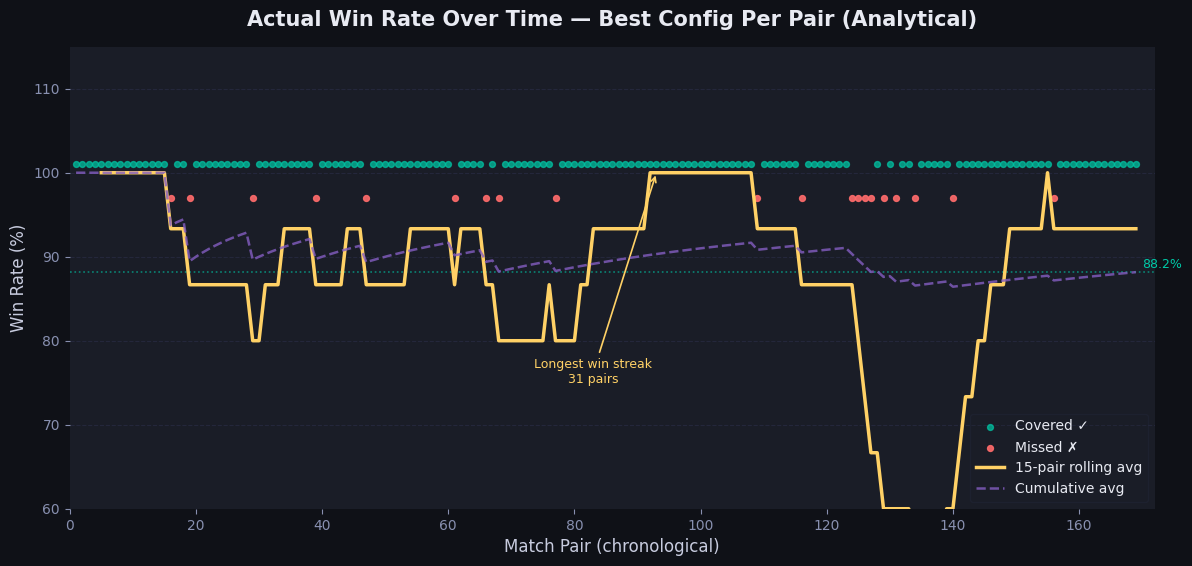

Chart 2: Profit margin distribution...
  Saved → viz_2_profit_margin_distribution.png


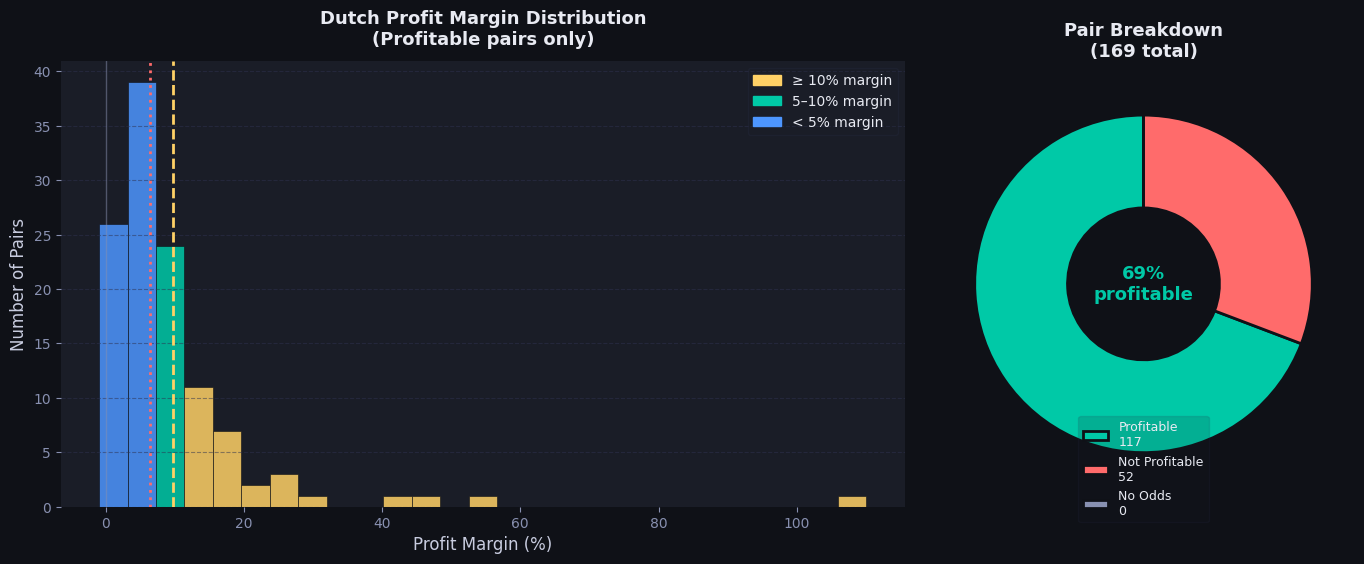

Chart 3: Streak timeline...
  Saved → viz_3_streak_timeline.png


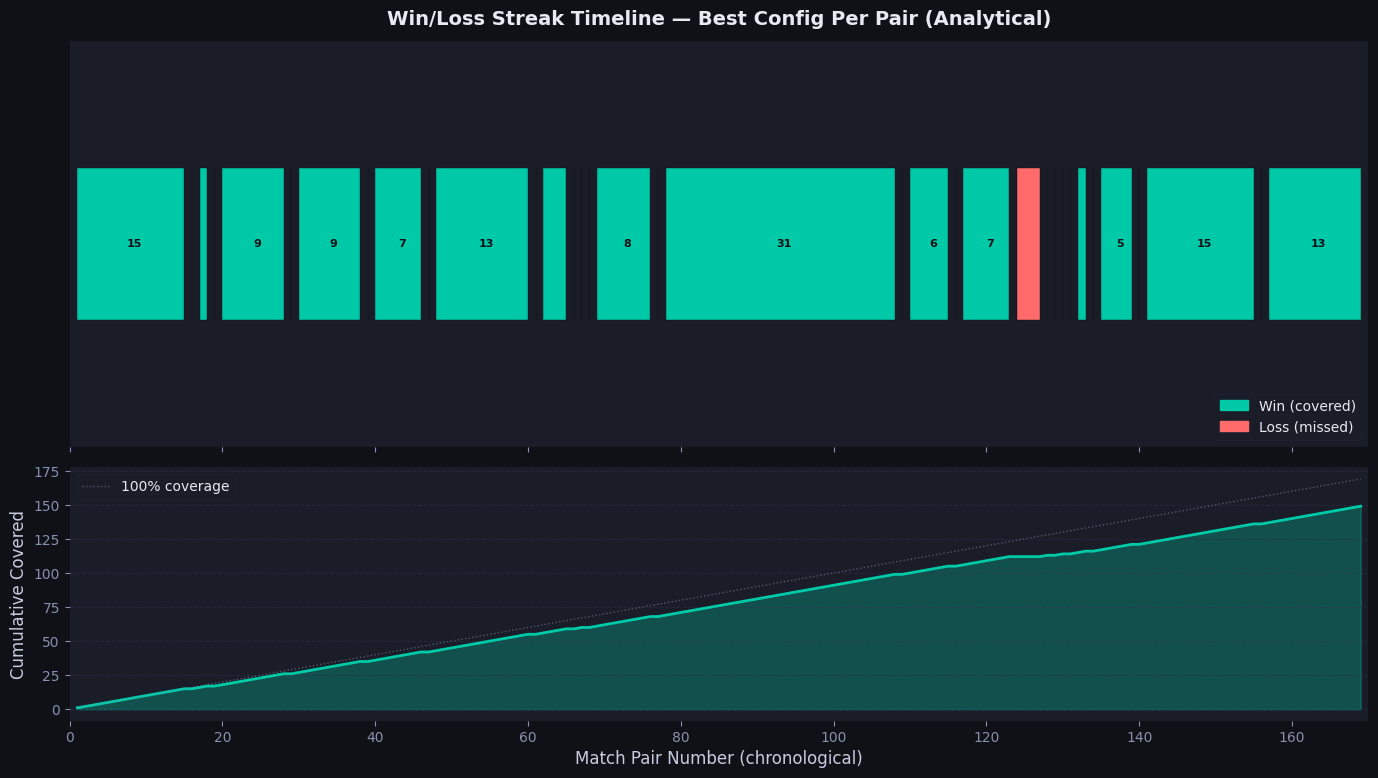

Chart 4: Exclusion heatmap...
  Saved → viz_4_exclusion_heatmap.png


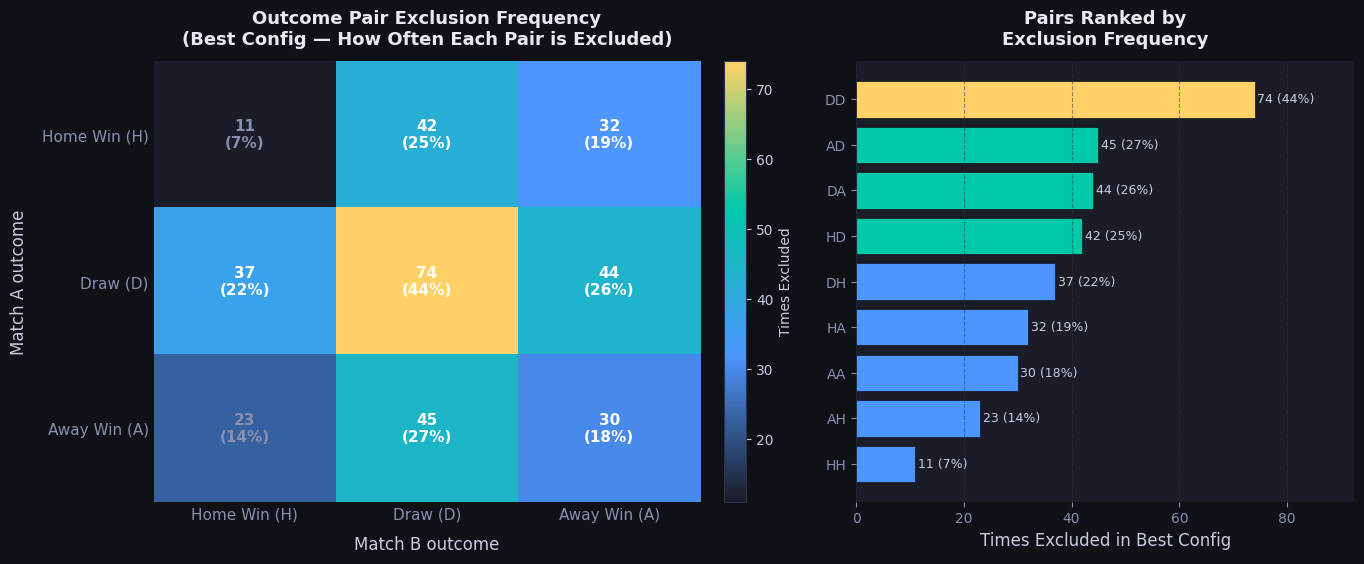


✅ All 4 charts generated.
Loading results for walkthrough...
  6,084 rows  |  36 config ranks  |  115 unique pairs

Pairs: rank-1 + profitable dutch + covered + has odds: 97
Selected pair: Southampton vs Arsenal  +  Man United vs Aston Villa
Date: 2025-05-25

STEP 1: THE PAIR AND ITS BEST CONFIG

  Date      : 2025-05-25
  Match A   : Southampton vs Arsenal
  Match B   : Man United vs Aston Villa

  Best config (rank #1):
  Excluded outcomes  : AD|AA
  Covered outcomes   : HH|HD|HA|DH|DD|DA|AH
  Analytical win rate: 95.0413%  (exact — no variance)

  Actual joint result : AH
  Covered by config  : ✅ YES

STEP 2: PROBABILITIES AND JOINT DISTRIBUTION

  Match A (Southampton vs Arsenal):
    Home win    0.3636  ██████████
    Draw        0.3636  ██████████
    Away win    0.2727  ████████

  Match B (Man United vs Aston Villa):
    Home win    0.8182  ████████████████████████
    Draw        0.0909  ██
    Away win    0.0909  ██

  Joint probabilities for all 9 outcomes:
  Pair   Joint P

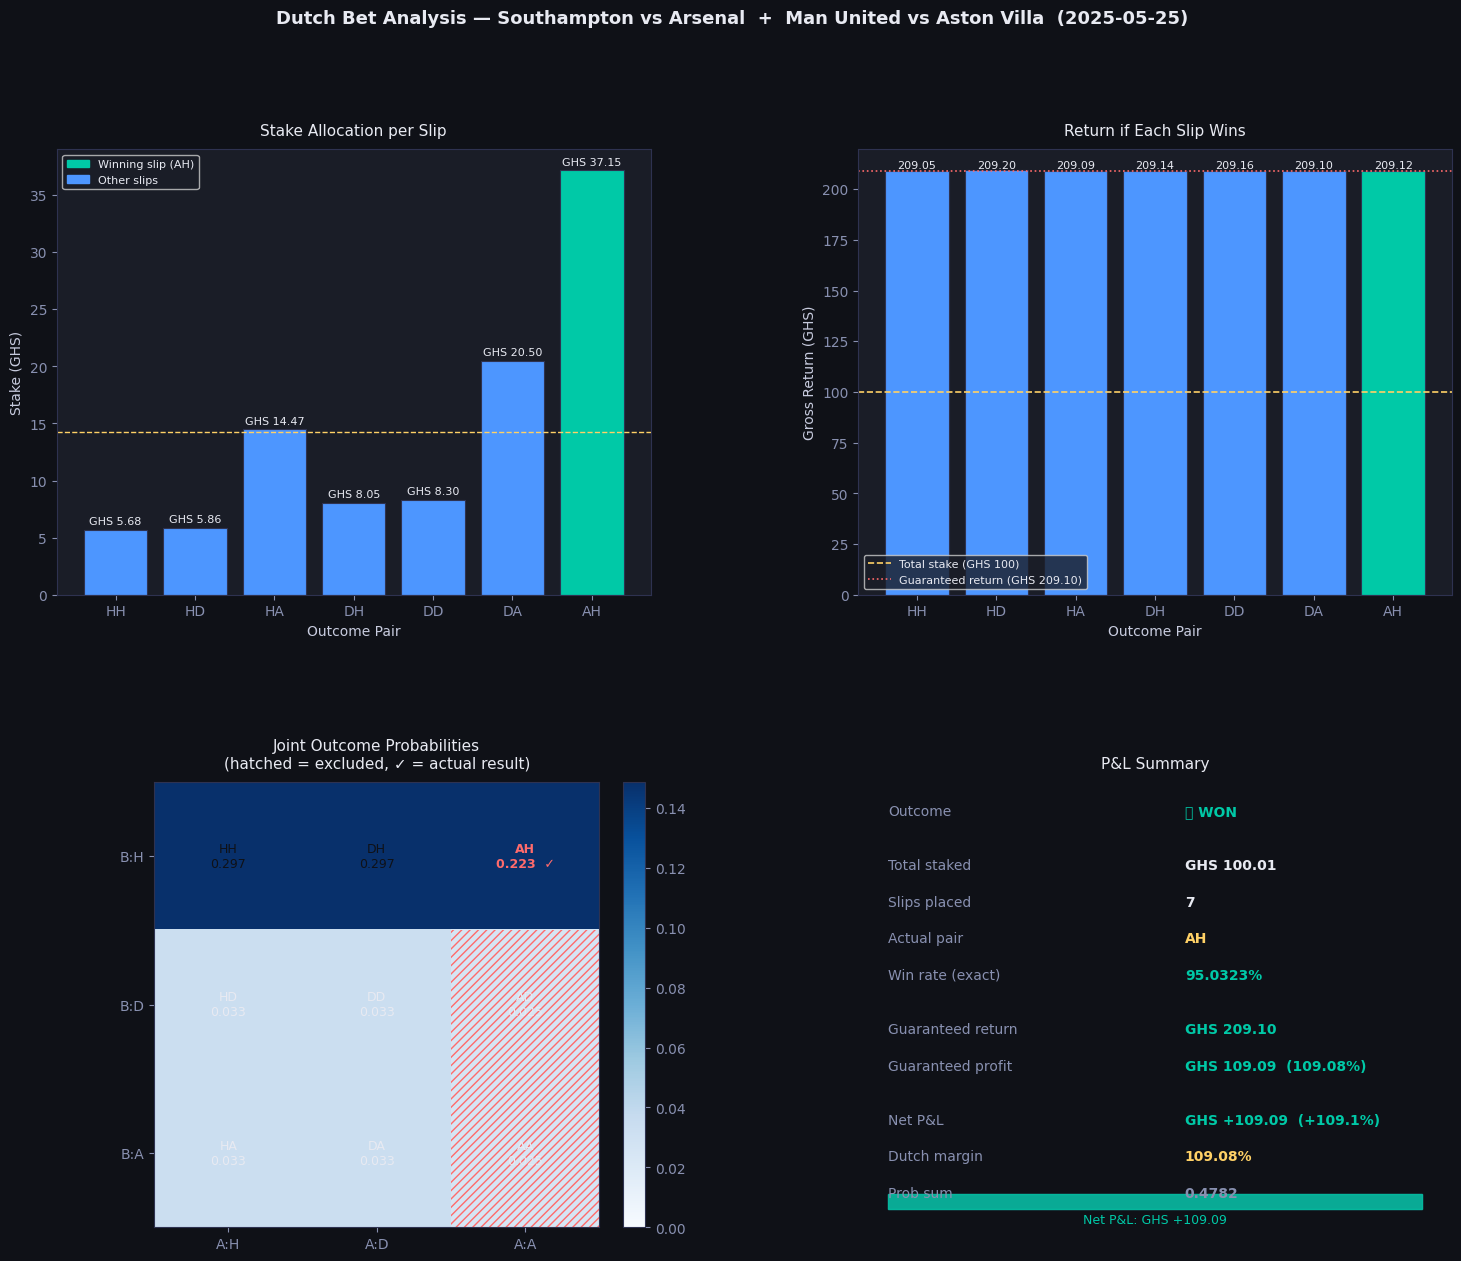


Chart saved → dutch_walkthrough.png

✅ Done.


In [ ]:

# -*- coding: utf-8 -*-
"""
EPL Selective Dutch — Analytical Edition
=========================================

For any exclusion config, the win rate is simply:
    W(cfg) = sum of pA[r1] * pB[r2]  for all (r1, r2) in remaining(cfg)

This is exact, zero variance, fully deterministic, and faster.

Run in Google Colab.
"""

import os
import itertools
import requests
import warnings
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

warnings.filterwarnings("ignore")


# ============================================================
# CONFIG
# ============================================================

LEAGUE          = "E0"
MIN_H2H_GAMES   = 10
NUM_EXCLUSIONS  = 2
TOTAL_STAKE     = 100.0
MIN_STAKE       = 0.20
OUTPUT_DIR      = "football_data"
COMBINED_CSV    = "epl_combined.csv"
RESULTS_CSV     = "epl_analytical_results.csv"

HISTORY_SEASONS = [
    "1011","1112","1213","1314","1415","1516",
    "1617","1718","1819","1920","2021","2122",
    "2223","2324","2425","2526"
]

TARGET_START = pd.Timestamp("2020-08-01")
TARGET_END   = pd.Timestamp("2026-07-31")

ODDS_COLS = ["B365H","B365D","B365A","PSH","PSD","PSA","WHH","WHD","WHA"]


# ============================================================
# SECTION 1: DATA DOWNLOAD & LOAD
# ============================================================

def download_epl_data(output_dir, seasons, league="E0"):
    base_url = "https://www.football-data.co.uk/mmz4281/"
    os.makedirs(output_dir, exist_ok=True)
    files = []
    print(f"Downloading {league} data for {len(seasons)} seasons...")
    for season in seasons:
        url      = f"{base_url}{season}/{league}.csv"
        filepath = os.path.join(output_dir, f"{league}_{season}.csv")
        if os.path.exists(filepath) and os.path.getsize(filepath) > 500:
            files.append(filepath)
            continue
        try:
            r = requests.get(url, timeout=15)
            r.raise_for_status()
            with open(filepath, "wb") as f:
                f.write(r.content)
            files.append(filepath)
        except requests.exceptions.HTTPError:
            pass
        except Exception as e:
            print(f"  Failed {url}: {e}")
    print(f"  {len(files)} files ready.\n")
    return files


def build_dataset(file_list, output_csv):
    if os.path.exists(output_csv):
        cached = pd.read_csv(output_csv, low_memory=False, nrows=1)
        if "B365H" in cached.columns:
            print(f"Loading cached dataset: {output_csv}")
            df = pd.read_csv(output_csv, low_memory=False)
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            return df.dropna(subset=["Date","HomeTeam","AwayTeam","FTR"])
        else:
            print(f"Cache missing odds columns — rebuilding {output_csv}...")

    keep_cols = ["Date","HomeTeam","AwayTeam","FTR"] + ODDS_COLS
    dfs = []
    for file in file_list:
        try:
            df   = pd.read_csv(file, low_memory=False)
            cols = [c for c in keep_cols if c in df.columns]
            df   = df[cols].copy()
            df.dropna(subset=["Date","HomeTeam","AwayTeam","FTR"], inplace=True)
            df["FTR"]  = df["FTR"].str.upper().str.strip()
            df         = df[df["FTR"].isin(["H","D","A"])]
            df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
            df.dropna(subset=["Date"], inplace=True)
            dfs.append(df)
        except Exception:
            pass

    combined = pd.concat(dfs, ignore_index=True).drop_duplicates(
        subset=["Date","HomeTeam","AwayTeam"]
    ).sort_values("Date").reset_index(drop=True)

    combined.to_csv(output_csv, index=False)
    print(f"Dataset saved: {output_csv} — {len(combined):,} rows")
    print(f"  Rows with B365H odds: {combined['B365H'].notna().sum():,}\n")
    return combined


# ============================================================
# SECTION 2: H2H & PROBABILITY UTILITIES
# ============================================================

def build_h2h_index(df):
    """Pre-index H2H by (HomeTeam, AwayTeam) for fast lookup."""
    return {
        (home, away): grp.sort_values("Date").reset_index(drop=True)
        for (home, away), grp in df.groupby(["HomeTeam","AwayTeam"])
    }

def get_h2h(index, home, away, before_date):
    grp = index.get((home, away), pd.DataFrame())
    return grp[grp["Date"] < before_date].reset_index(drop=True) if not grp.empty else grp

def outcome_probs(h2h_df):
    counts = h2h_df["FTR"].value_counts(normalize=True)
    return {o: float(counts.get(o, 0)) for o in ["H","D","A"]}

def extract_odds(row):
    """Return (odds_dict, source) using B365 first, then PS, then WH."""
    for h_col, d_col, a_col in [("B365H","B365D","B365A"),("PSH","PSD","PSA"),("WHH","WHD","WHA")]:
        try:
            h, d, a = float(row[h_col]), float(row[d_col]), float(row[a_col])
            if not any(pd.isna(x) for x in [h, d, a]):
                return {"H": h, "D": d, "A": a}, h_col[:-1]
        except Exception:
            continue
    return None, None


# ============================================================
# SECTION 3: EXCLUSION CONFIG GENERATION
# ============================================================

def generate_configs(num_exclusions=2):
    all_pairs = ["".join(p) for p in itertools.product(["H","D","A"], repeat=2)]
    return [
        {"excluded": list(ex), "remaining": [p for p in all_pairs if p not in ex]}
        for ex in itertools.combinations(all_pairs, num_exclusions)
    ]


# ============================================================
# SECTION 4: ANALYTICAL WIN RATE  (replaces Monte Carlo)
# ============================================================

def analytical_win_rate(pA, pB, remaining):
    """
    Exact win rate for a config — no simulation needed.

    For each covered outcome pair (r1, r2), the joint probability is simply:
        pA[r1] * pB[r2]

    The win rate is the sum of these over all covered pairs.
    This is exact and deterministic — no random draws, no variance.
    """
    return sum(pA[pair[0]] * pB[pair[1]] for pair in remaining)


def rank_configs(pA, pB, configs):
    """
    Score and rank all configs analytically, then compute streak stats
    on the exact joint probability distribution for reference.
    """
    results = []
    all_pairs = [r1 + r2 for r1 in "HDA" for r2 in "HDA"]
    joint_probs = {p: pA[p[0]] * pB[p[1]] for p in all_pairs}

    for cfg in configs:
        win_rate = analytical_win_rate(pA, pB, cfg["remaining"])
        results.append({
            "excluded"    : cfg["excluded"],
            "remaining"   : cfg["remaining"],
            "win_rate_pct": round(win_rate * 100, 4),
        })

    return sorted(results, key=lambda x: x["win_rate_pct"], reverse=True)


# ============================================================
# SECTION 5: DUTCHING CALCULATOR
# ============================================================

def dutching_calc(remaining_pairs, odds_a, odds_b, total_stake, min_stake):
    slips = []
    for pair in remaining_pairs:
        parlay = round(odds_a[pair[0]] * odds_b[pair[1]], 3)
        slips.append({"pair": pair, "parlay_odds": parlay, "implied_prob": 1.0 / parlay})

    prob_sum = sum(s["implied_prob"] for s in slips)
    is_dutch = prob_sum < 1.0

    if not is_dutch:
        return {"is_dutch": False, "prob_sum": round(prob_sum, 4),
                "profit": None, "profit_pct": None, "allocations": []}

    guar = total_stake / prob_sum
    allocs = []
    for s in slips:
        stake = round(max(total_stake * (s["implied_prob"] / prob_sum), min_stake), 2)
        allocs.append({**s, "stake": stake, "return": round(stake * s["parlay_odds"], 2)})

    actual_stake = sum(a["stake"] for a in allocs)
    profit       = round(guar - actual_stake, 2)

    return {
        "is_dutch"          : True,
        "prob_sum"          : round(prob_sum, 4),
        "guaranteed_return" : round(guar, 2),
        "actual_stake"      : round(actual_stake, 2),
        "profit"            : profit,
        "profit_pct"        : round((profit / actual_stake) * 100, 2),
        "allocations"       : allocs,
    }


# ============================================================
# SECTION 6: MAIN PIPELINE
# ============================================================

def run_pipeline():

    # ── Download & build ──────────────────────────────────────────────
    files  = download_epl_data(OUTPUT_DIR, HISTORY_SEASONS, LEAGUE)
    df_all = build_dataset(files, COMBINED_CSV)

    # ── Pre-index H2H ─────────────────────────────────────────────────
    print("Building H2H index...")
    h2h_index = build_h2h_index(df_all)
    print(f"  {len(h2h_index):,} matchup orientations indexed.\n")

    # ── Target fixtures ───────────────────────────────────────────────
    df_target = df_all[
        (df_all["Date"] >= TARGET_START) & (df_all["Date"] <= TARGET_END)
    ].copy().reset_index(drop=True)
    df_target["DateOnly"] = df_target["Date"].dt.date

    print(f"Target fixtures (2020–2026): {len(df_target):,} matches")
    print(f"Date range: {df_target['Date'].min().date()} → {df_target['Date'].max().date()}")
    print(f"Rows with B365 odds: {df_target['B365H'].notna().sum():,}\n")

    configs = generate_configs(NUM_EXCLUSIONS)
    print(f"Exclusion configs per pair : {len(configs)}")
    print(f"Win rate method            : Analytical (exact)")
    print(f"Min H2H games required     : {MIN_H2H_GAMES}\n")

    # ── Main loop ─────────────────────────────────────────────────────
    skipped, valid = 0, 0
    all_records    = []

    for date in sorted(df_target["DateOnly"].unique()):
        day = df_target[df_target["DateOnly"] == date]
        if len(day) < 2:
            continue

        for i, j in itertools.combinations(day.index.tolist(), 2):
            rA = df_target.loc[i]
            rB = df_target.loc[j]
            ts = pd.Timestamp(date)

            h2h_a = get_h2h(h2h_index, rA["HomeTeam"], rA["AwayTeam"], ts)
            h2h_b = get_h2h(h2h_index, rB["HomeTeam"], rB["AwayTeam"], ts)

            if len(h2h_a) < MIN_H2H_GAMES or len(h2h_b) < MIN_H2H_GAMES:
                skipped += 1
                continue

            valid += 1
            pA = outcome_probs(h2h_a)
            pB = outcome_probs(h2h_b)

            # ── Analytical ranking (no simulation) ────────────────────
            ranked = rank_configs(pA, pB, configs)

            actual_pair = rA["FTR"] + rB["FTR"]
            odds_a, src_a = extract_odds(rA)
            odds_b, src_b = extract_odds(rB)

            best_cfg = ranked[0]
            if odds_a and odds_b:
                dutch = dutching_calc(
                    best_cfg["remaining"], odds_a, odds_b, TOTAL_STAKE, MIN_STAKE
                )
            else:
                dutch = {"is_dutch": None, "prob_sum": None,
                         "profit": None, "profit_pct": None}

            for rank_i, cfg in enumerate(ranked):
                rec = {
                    # Fixture info
                    "date"              : date,
                    "match_a"           : f"{rA['HomeTeam']} vs {rA['AwayTeam']}",
                    "match_b"           : f"{rB['HomeTeam']} vs {rB['AwayTeam']}",
                    "n_h2h_a"           : len(h2h_a),
                    "n_h2h_b"           : len(h2h_b),
                    "prob_a"            : f"H={pA['H']:.4f} D={pA['D']:.4f} A={pA['A']:.4f}",
                    "prob_b"            : f"H={pB['H']:.4f} D={pB['D']:.4f} A={pB['A']:.4f}",
                    # Real odds
                    "odds_src"          : src_a if src_a else "N/A",
                    "odds_a_H"          : odds_a["H"] if odds_a else None,
                    "odds_a_D"          : odds_a["D"] if odds_a else None,
                    "odds_a_A"          : odds_a["A"] if odds_a else None,
                    "odds_b_H"          : odds_b["H"] if odds_b else None,
                    "odds_b_D"          : odds_b["D"] if odds_b else None,
                    "odds_b_A"          : odds_b["A"] if odds_b else None,
                    # Config & analytical results
                    "actual_pair"       : actual_pair,
                    "config_rank"       : rank_i + 1,
                    "excluded"          : "|".join(cfg["excluded"]),
                    "remaining"         : "|".join(cfg["remaining"]),
                    "win_rate_pct"      : cfg["win_rate_pct"],   # exact, no variance
                    "actual_covered"    : actual_pair in set(cfg["remaining"]),
                    # Dutching (rank 1 only)
                    "dutch_is_profitable": dutch["is_dutch"]   if rank_i == 0 else None,
                    "dutch_prob_sum"     : dutch["prob_sum"]   if rank_i == 0 else None,
                    "dutch_profit"       : dutch["profit"]     if rank_i == 0 else None,
                    "dutch_profit_pct"   : dutch["profit_pct"] if rank_i == 0 else None,
                }
                all_records.append(rec)

    # ── Summary ───────────────────────────────────────────────────────
    print(f"Pairs processed : {valid:,}")
    print(f"Pairs skipped   : {skipped:,}  (< {MIN_H2H_GAMES} H2H games)")

    if not all_records:
        print("\nNo valid pairs found.")
        return pd.DataFrame()

    results_df = pd.DataFrame(all_records)
    best_df    = results_df[results_df["config_rank"] == 1].copy().sort_values("date")

    has_odds   = best_df["odds_a_H"].notna().sum()
    actual_wr  = best_df["actual_covered"].mean()
    avg_wr     = best_df["win_rate_pct"].mean()

    print(f"Pairs with real odds       : {has_odds} / {len(best_df)}")

    print(f"\n{'='*55}")
    print(f"ACCURACY — BEST CONFIG PER PAIR")
    print(f"{'='*55}")
    print(f"  Pairs evaluated    : {len(best_df):,}")
    print(f"  Actual win rate    : {actual_wr*100:.2f}%  "
          f"({best_df['actual_covered'].sum()} / {len(best_df)} covered)")
    print(f"  Avg analytical WR  : {avg_wr:.4f}%  (exact — no simulation variance)")

    dutch_df = best_df[best_df["dutch_is_profitable"] == True]
    if len(dutch_df) > 0:
        print(f"  Profitable dutch   : {len(dutch_df)} / {has_odds} pairs with odds  "
              f"(avg margin: {dutch_df['dutch_profit_pct'].mean():.2f}%)")

    # ── Win rate by rank ──────────────────────────────────────────────
    print(f"\n  WIN RATE BY CONFIG RANK:")
    for r in range(1, 6):
        rdf = results_df[results_df["config_rank"] == r]
        print(f"  Rank #{r}: {rdf['actual_covered'].mean()*100:.2f}%")

    # ── Save ──────────────────────────────────────────────────────────
    results_df.to_csv(RESULTS_CSV, index=False)
    print(f"\nFull results saved → {RESULTS_CSV}")

    print(f"\nSAMPLE — Best config per pair (first 10 rows):")
    print(best_df[["date","match_a","match_b","excluded","win_rate_pct",
                   "odds_src","odds_a_H","odds_a_A",
                   "actual_pair","actual_covered","dutch_profit_pct"]
                 ].head(10).to_string(index=False))

    return results_df


# ── Run ───────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    results = run_pipeline()


# ============================================================
# SECTION 7: VISUALISATIONS
# (Run after pipeline has produced epl_analytical_results.csv)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.facecolor" : "#0F1117",
    "axes.facecolor"   : "#1A1D27",
    "axes.edgecolor"   : "#2E3250",
    "axes.labelcolor"  : "#C8CCDF",
    "xtick.color"      : "#8890B0",
    "ytick.color"      : "#8890B0",
    "text.color"       : "#E8EAF2",
    "grid.color"       : "#2E3250",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.family"      : "DejaVu Sans",
})

TEAL   = "#00C9A7"
CORAL  = "#FF6B6B"
GOLD   = "#FFD166"
PURPLE = "#845EC2"
BLUE   = "#4D96FF"
BG     = "#0F1117"
PANEL  = "#1A1D27"
BORDER = "#2E3250"
MUTED  = "#8890B0"


def save(fig, name):
    fig.savefig(name, dpi=180, bbox_inches="tight", facecolor=BG)
    print(f"  Saved → {name}")
    plt.show()


print("Loading results...")
df   = pd.read_csv(RESULTS_CSV, low_memory=False)
df["date"] = pd.to_datetime(df["date"])
best = df[df["config_rank"] == 1].copy().sort_values("date").reset_index(drop=True)
best["match_num"] = range(1, len(best) + 1)

print(f"  {len(best)} pairs  |  {best['date'].min().date()} → {best['date'].max().date()}")
print(f"  Overall actual win rate: {best['actual_covered'].mean()*100:.1f}%\n")


# ══════════════════════════════════════════════════════════════════════════
# CHART 1 — Win Rate Over Time
# ══════════════════════════════════════════════════════════════════════════
print("Chart 1: Win rate over time...")

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

covered  = best["actual_covered"].astype(int).values
x        = best["match_num"].values
roll_win = pd.Series(covered).rolling(window=15, min_periods=5).mean() * 100
cum_win  = pd.Series(covered).expanding().mean() * 100

wins_x   = x[covered == 1]
losses_x = x[covered == 0]
ax.scatter(wins_x,   [101] * len(wins_x),   color=TEAL,  s=18, alpha=0.7, zorder=3, label="Covered ✓")
ax.scatter(losses_x, [97]  * len(losses_x), color=CORAL, s=18, alpha=0.9, zorder=3, label="Missed ✗")
ax.plot(x, roll_win, color=GOLD,   lw=2.5, label="15-pair rolling avg", zorder=4)
ax.plot(x, cum_win,  color=PURPLE, lw=1.8, linestyle="--", label="Cumulative avg", zorder=4, alpha=0.8)
ax.axhline(best["actual_covered"].mean() * 100, color=TEAL, lw=1.2, linestyle=":", alpha=0.6)
ax.axhline(50, color=MUTED, lw=0.8, linestyle=":", alpha=0.4)
ax.text(x[-1] + 1, best["actual_covered"].mean() * 100 + 0.5,
        f"{best['actual_covered'].mean()*100:.1f}%", color=TEAL, fontsize=9)

ax.set_xlim(0, len(best) + 3)
ax.set_ylim(60, 115)
ax.set_xlabel("Match Pair (chronological)", fontsize=12)
ax.set_ylabel("Win Rate (%)", fontsize=12)
ax.set_title("Actual Win Rate Over Time — Best Config Per Pair (Analytical)", fontsize=15,
             fontweight="bold", color="#E8EAF2", pad=15)
ax.legend(loc="lower right", framealpha=0.2, edgecolor=BORDER)
ax.grid(True, axis="y")
ax.spines[:].set_visible(False)

# Annotate longest win streak
runs, cur_len, cur_type, start = [], 1, covered[0], 0
for idx in range(1, len(covered)):
    if covered[idx] == cur_type:
        cur_len += 1
    else:
        runs.append((start + 1, cur_len, int(cur_type)))
        cur_len, cur_type, start = 1, covered[idx], idx
runs.append((start + 1, cur_len, int(cur_type)))
win_runs = [(s, l) for s, l, t in runs if t == 1]
if win_runs:
    max_s, max_l = max(win_runs, key=lambda r: r[1])
    sx = max_s + max_l // 2
    ax.annotate(f"Longest win streak\n{max_l} pairs",
                xy=(sx, roll_win.iloc[min(sx - 1, len(roll_win) - 1)]),
                xytext=(sx - 10, 75),
                arrowprops=dict(arrowstyle="->", color=GOLD, lw=1.2),
                color=GOLD, fontsize=9, ha="center")

save(fig, "viz_1_win_rate_over_time.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 2 — Dutch Profit Margin Distribution
# ══════════════════════════════════════════════════════════════════════════
print("Chart 2: Profit margin distribution...")

profitable = best[best["dutch_is_profitable"] == True]["dutch_profit_pct"].dropna()
not_dutch  = best[best["dutch_is_profitable"] != True]
no_odds    = best[best["odds_a_H"].isna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [2, 1]})
fig.patch.set_facecolor(BG)

ax = axes[0]
ax.set_facecolor(PANEL)
bins = np.linspace(profitable.min() - 1, profitable.max() + 1, 28)
n, b, patches = ax.hist(profitable, bins=bins, color=TEAL, edgecolor=BG, linewidth=0.5, alpha=0.85)
for patch, left in zip(patches, b[:-1]):
    patch.set_facecolor(GOLD if left >= 10 else TEAL if left >= 5 else BLUE)
ax.axvline(profitable.mean(),   color=GOLD,  lw=2, linestyle="--", label=f"Mean {profitable.mean():.1f}%")
ax.axvline(profitable.median(), color=CORAL, lw=2, linestyle=":",  label=f"Median {profitable.median():.1f}%")
ax.axvline(0, color=MUTED, lw=1, alpha=0.5)
legend_patches = [
    mpatches.Patch(color=GOLD,  label="≥ 10% margin"),
    mpatches.Patch(color=TEAL,  label="5–10% margin"),
    mpatches.Patch(color=BLUE,  label="< 5% margin"),
]
ax.legend(handles=legend_patches, framealpha=0.2, edgecolor=BORDER, loc="upper right")
ax.set_xlabel("Profit Margin (%)", fontsize=12)
ax.set_ylabel("Number of Pairs", fontsize=12)
ax.set_title("Dutch Profit Margin Distribution\n(Profitable pairs only)", fontsize=13,
             fontweight="bold", pad=12)
ax.grid(True, axis="y")
ax.spines[:].set_visible(False)

ax2 = axes[1]
ax2.set_facecolor(PANEL)
total    = len(best)
n_profit = len(profitable)
n_noprof = len(not_dutch[not_dutch["odds_a_H"].notna()])
n_nodata = len(no_odds)
wedges, _ = ax2.pie(
    [n_profit, n_noprof, n_nodata],
    colors=[TEAL, CORAL, MUTED], startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
)
ax2.text(0, 0, f"{n_profit/total*100:.0f}%\nprofitable",
         ha="center", va="center", fontsize=13, fontweight="bold", color=TEAL)
ax2.legend(wedges,
           [f"Profitable\n{n_profit}", f"Not Profitable\n{n_noprof}", f"No Odds\n{n_nodata}"],
           loc="lower center", framealpha=0.15, edgecolor=BORDER,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))
ax2.set_title(f"Pair Breakdown\n({total} total)", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout(pad=2)
save(fig, "viz_2_profit_margin_distribution.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 3 — Win/Loss Streak Timeline
# ══════════════════════════════════════════════════════════════════════════
print("Chart 3: Streak timeline...")

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                      gridspec_kw={"height_ratios": [1.6, 1]})
fig.patch.set_facecolor(BG)

streak_runs = []
i = 0
while i < len(covered):
    val = covered[i]; j = i
    while j < len(covered) and covered[j] == val:
        j += 1
    streak_runs.append((i + 1, j, int(val), j - i))
    i = j

ax_top.set_facecolor(PANEL)
for start, end, outcome, length in streak_runs:
    color = TEAL if outcome == 1 else CORAL
    ax_top.barh(0, end - start, left=start, height=0.6,
                color=color, edgecolor=BG, linewidth=0.3)
    if length >= 5:
        ax_top.text(start + length / 2, 0, str(length),
                    ha="center", va="center", fontsize=8, fontweight="bold", color=BG)

ax_top.set_xlim(0, len(best) + 1)
ax_top.set_ylim(-0.8, 0.8)
ax_top.set_yticks([])
ax_top.set_title("Win/Loss Streak Timeline — Best Config Per Pair (Analytical)",
                 fontsize=14, fontweight="bold", pad=12)
ax_top.legend(handles=[mpatches.Patch(color=TEAL, label="Win (covered)"),
                        mpatches.Patch(color=CORAL, label="Loss (missed)")],
              loc="lower right", framealpha=0.2, edgecolor=BORDER)
ax_top.spines[:].set_visible(False)

ax_bot.set_facecolor(PANEL)
cum = np.cumsum(covered)
ax_bot.fill_between(best["match_num"], cum, alpha=0.3, color=TEAL)
ax_bot.plot(best["match_num"], cum, color=TEAL, lw=2)
ax_bot.plot(best["match_num"], np.arange(1, len(best) + 1),
            color=MUTED, lw=1, linestyle=":", alpha=0.5, label="100% coverage")
ax_bot.set_xlabel("Match Pair Number (chronological)", fontsize=12)
ax_bot.set_ylabel("Cumulative Covered", fontsize=12)
ax_bot.legend(framealpha=0.2, edgecolor=BORDER)
ax_bot.grid(True, axis="y")
ax_bot.spines[:].set_visible(False)

plt.tight_layout(pad=1.5)
save(fig, "viz_3_streak_timeline.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 4 — Exclusion Heatmap
# ══════════════════════════════════════════════════════════════════════════
print("Chart 4: Exclusion heatmap...")

exclude_counts = Counter()
for excl_str in best["excluded"]:
    for pair in excl_str.split("|"):
        exclude_counts[pair.strip()] += 1

all_outcomes = list("HDA")
matrix = np.zeros((3, 3))
for i, oa in enumerate(all_outcomes):
    for j, ob in enumerate(all_outcomes):
        matrix[i, j] = exclude_counts.get(oa + ob, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.2, 1]})
fig.patch.set_facecolor(BG)

ax = axes[0]
ax.set_facecolor(PANEL)
cmap = LinearSegmentedColormap.from_list("dutch", [PANEL, BLUE, TEAL, GOLD])
im   = ax.imshow(matrix, cmap=cmap, aspect="auto")
labels_full = ["Home Win (H)", "Draw (D)", "Away Win (A)"]
ax.set_xticks(range(3)); ax.set_xticklabels(labels_full, fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(labels_full, fontsize=11)
ax.set_xlabel("Match B outcome", fontsize=12, labelpad=10)
ax.set_ylabel("Match A outcome", fontsize=12, labelpad=10)
ax.set_title("Outcome Pair Exclusion Frequency\n(Best Config — How Often Each Pair is Excluded)",
             fontsize=13, fontweight="bold", pad=12)
total_pairs = len(best)
for i in range(3):
    for j in range(3):
        val = int(matrix[i, j])
        ax.text(j, i, f"{val}\n({val/total_pairs*100:.0f}%)",
                ha="center", va="center", fontsize=11, fontweight="bold",
                color="white" if matrix[i, j] > matrix.max() * 0.4 else MUTED)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Times Excluded", color="#C8CCDF")
cbar.ax.yaxis.set_tick_params(color="#C8CCDF")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#C8CCDF")
ax.spines[:].set_visible(False)
ax.tick_params(length=0)

ax2 = axes[1]
ax2.set_facecolor(PANEL)
sorted_pairs = sorted(exclude_counts.items(), key=lambda x: x[1], reverse=True)
pair_labels  = [p for p, _ in sorted_pairs]
pair_values  = [v for _, v in sorted_pairs]
bar_colors   = [GOLD if v == max(pair_values) else TEAL if v > np.mean(pair_values) else BLUE
                for v in pair_values]
bars = ax2.barh(pair_labels, pair_values, color=bar_colors, edgecolor=BG, linewidth=0.5)
for bar, val in zip(bars, pair_values):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val} ({val/total_pairs*100:.0f}%)", va="center", fontsize=9, color="#C8CCDF")
ax2.set_xlabel("Times Excluded in Best Config", fontsize=12)
ax2.set_title("Pairs Ranked by\nExclusion Frequency", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlim(0, max(pair_values) * 1.25)
ax2.grid(True, axis="x")
ax2.spines[:].set_visible(False)
ax2.invert_yaxis()

plt.tight_layout(pad=2)
save(fig, "viz_4_exclusion_heatmap.png")

print("\n✅ All 4 charts generated.")


# ============================================================
# SECTION 8: SINGLE PAIR WALKTHROUGH + VISUALISATION
# (Run after pipeline — picks best profitable pair and walks through it)
# ============================================================

import ast

TOTAL_STAKE = 100.0
MIN_STAKE   = 0.20

print("Loading results for walkthrough...")
df = pd.read_csv(RESULTS_CSV, low_memory=False)
print(f"  {len(df):,} rows  |  {df['config_rank'].nunique()} config ranks  |  "
      f"{df[df['config_rank']==1]['date'].nunique()} unique pairs\n")

candidates = df[
    (df["config_rank"]        == 1) &
    (df["dutch_is_profitable"] == True) &
    (df["actual_covered"]     == True) &
    (df["odds_a_H"].notna())
].copy()

print(f"Pairs: rank-1 + profitable dutch + covered + has odds: {len(candidates)}")
test_row = candidates.sort_values("dutch_profit_pct", ascending=False).iloc[0]
print(f"Selected pair: {test_row['match_a']}  +  {test_row['match_b']}")
print(f"Date: {test_row['date']}\n")

pair_df = df[
    (df["date"]    == test_row["date"]) &
    (df["match_a"] == test_row["match_a"]) &
    (df["match_b"] == test_row["match_b"])
].sort_values("config_rank").reset_index(drop=True)


# ── STEP 1 ───────────────────────────────────────────────────────────────
print("=" * 65)
print("STEP 1: THE PAIR AND ITS BEST CONFIG")
print("=" * 65)
print(f"\n  Date      : {test_row['date']}")
print(f"  Match A   : {test_row['match_a']}")
print(f"  Match B   : {test_row['match_b']}")
print(f"\n  Best config (rank #1):")
print(f"  Excluded outcomes  : {test_row['excluded']}")
print(f"  Covered outcomes   : {test_row['remaining']}")
print(f"  Analytical win rate: {test_row['win_rate_pct']:.4f}%  (exact — no variance)")
print(f"\n  Actual joint result : {test_row['actual_pair']}")
print(f"  Covered by config  : {'✅ YES' if test_row['actual_covered'] else '❌ NO'}")


# ── STEP 2 ───────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP 2: PROBABILITIES AND JOINT DISTRIBUTION")
print("=" * 65)

pA = {p.split("=")[0]: float(p.split("=")[1]) for p in test_row['prob_a'].split()}
pB = {p.split("=")[0]: float(p.split("=")[1]) for p in test_row['prob_b'].split()}

print(f"\n  Match A ({test_row['match_a']}):")
for o, name in [("H","Home win"),("D","Draw"),("A","Away win")]:
    bar = "█" * int(pA[o] * 30)
    print(f"    {name:<10}  {pA[o]:.4f}  {bar}")

print(f"\n  Match B ({test_row['match_b']}):")
for o, name in [("H","Home win"),("D","Draw"),("A","Away win")]:
    bar = "█" * int(pB[o] * 30)
    print(f"    {name:<10}  {pB[o]:.4f}  {bar}")

all_pairs = ["".join(p) for p in itertools.product(["H","D","A"], repeat=2)]
jp = {pair: pA[pair[0]] * pB[pair[1]] for pair in all_pairs}
excluded_set = set(test_row['excluded'].split("|"))

print(f"\n  Joint probabilities for all 9 outcomes:")
print(f"  {'Pair':<6} {'Joint Prob':>10}  {'Visual'}")
print(f"  {'-'*45}")
for pair in sorted(jp, key=jp.get, reverse=True):
    bar    = "█" * int(jp[pair] * 60)
    marker = "  ← EXCLUDED" if pair in excluded_set else ""
    print(f"  {pair:<6} {jp[pair]:>10.4f}  {bar}{marker}")

covered_pairs = [p for p in all_pairs if p not in excluded_set]
exact_win_rate = sum(jp[p] for p in covered_pairs)
print(f"\n  Exact win rate (sum of covered joint probs): {exact_win_rate:.6f}  ({exact_win_rate*100:.4f}%)")


# ── STEP 3 ───────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP 3: ALL 36 CONFIGS RANKED (ANALYTICAL)")
print("=" * 65)
print(f"\n  {'Rank':<5} {'Excluded':<10} {'Remaining':<45} {'Win Rate':>10}")
print(f"  {'-'*75}")
for _, row in pair_df.iterrows():
    marker = "  ◀ BEST" if row['config_rank'] == 1 else ""
    print(f"  {int(row['config_rank']):<5} {row['excluded']:<10} {row['remaining']:<45} "
          f"{row['win_rate_pct']:>9.4f}%{marker}")


# ── STEP 4 ───────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print(f"STEP 4: DUTCHING STAKE ALLOCATION — GHS {TOTAL_STAKE:.2f}  ({test_row['odds_src']} odds)")
print("=" * 65)

odds_a = {"H": test_row["odds_a_H"], "D": test_row["odds_a_D"], "A": test_row["odds_a_A"]}
odds_b = {"H": test_row["odds_b_H"], "D": test_row["odds_b_D"], "A": test_row["odds_b_A"]}

print(f"\n  {test_row['match_a']}:  H={odds_a['H']}  D={odds_a['D']}  A={odds_a['A']}")
print(f"  {test_row['match_b']}:  H={odds_b['H']}  D={odds_b['D']}  A={odds_b['A']}")

remaining_pairs = test_row['remaining'].split("|")
slips = []
for pair in remaining_pairs:
    parlay = round(odds_a[pair[0]] * odds_b[pair[1]], 3)
    slips.append({"pair": pair, "parlay_odds": parlay, "implied_prob": 1.0 / parlay})

prob_sum = sum(s["implied_prob"] for s in slips)
is_dutch = prob_sum < 1.0

print(f"\n  Covered outcomes   : {remaining_pairs}  ({len(remaining_pairs)} slips)")
print(f"  Prob sum           : {prob_sum:.4f}  "
      f"({'✅ Profitable' if is_dutch else '❌ Not profitable'})")

allocs = []
if is_dutch:
    guar = TOTAL_STAKE / prob_sum
    for s in slips:
        stake = round(max(TOTAL_STAKE * (s["implied_prob"] / prob_sum), MIN_STAKE), 2)
        ret   = round(stake * s["parlay_odds"], 2)
        allocs.append({**s, "stake": stake, "return": ret})

    total_staked = sum(a["stake"] for a in allocs)
    profit       = round(guar - total_staked, 2)
    profit_pct   = round((profit / total_staked) * 100, 2)

    print(f"\n  Guaranteed return  : GHS {TOTAL_STAKE:.2f} / {prob_sum:.4f} = GHS {guar:.2f}")
    print(f"\n  {'Slip':<5} {'Pair':<6} {'Parlay Odds':>11}  {'Impl Prob':>10}  {'Stake (GHS)':>11}  {'Return (GHS)':>12}")
    print(f"  {'-'*60}")
    for k, a in enumerate(allocs):
        print(f"  {k+1:<5} {a['pair']:<6} {a['parlay_odds']:>11.3f}  {a['implied_prob']:>10.6f}  "
              f"{a['stake']:>11.2f}  {a['return']:>12.2f}")
    print(f"  {'-'*60}")
    print(f"  {'':5} {'TOTAL':<6} {'':>11}  {'':>10}  {total_staked:>11.2f}")
    print(f"\n  Guaranteed profit  : GHS {profit:.2f}  ({profit_pct}%)")


# ── STEP 5 ───────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP 5: ACTUAL RESULT AND P&L")
print("=" * 65)

actual_pair  = test_row["actual_pair"]
covered      = bool(test_row["actual_covered"])
winning_slip = next((a for a in allocs if a["pair"] == actual_pair), None) if is_dutch else None
won          = covered and (winning_slip is not None)

print(f"\n  Actual joint outcome : {actual_pair}")
print(f"  Excluded outcomes    : {test_row['excluded']}")
print(f"  Result               : {'✅ COVERED' if covered else '❌ MISSED'}")

if won:
    other_cost = sum(a["stake"] for a in allocs if a["pair"] != actual_pair)
    print(f"\n  Winning slip         : {actual_pair}  @  {winning_slip['parlay_odds']} parlay odds")
    print(f"  Stake on winner      : GHS {winning_slip['stake']:.2f}")
    print(f"  Lost on other slips  : GHS {other_cost:.2f}")
    print(f"  Gross return         : GHS {winning_slip['return']:.2f}")
    print(f"  Net profit           : GHS {profit:.2f}  ({profit_pct}% on GHS {total_staked:.2f})")
elif not covered:
    print(f"\n  All {len(allocs)} slips lost.")
    print(f"  Total loss           : GHS {total_staked:.2f}")


# ── STEP 6: VISUALISATION ─────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP 6: VISUALISATION")
print("=" * 65)

fig = plt.figure(figsize=(18, 14), facecolor="#0F1117")
fig.suptitle(
    f"Dutch Bet Analysis — {test_row['match_a']}  +  {test_row['match_b']}  ({test_row['date']})",
    fontsize=13, color="#E8EAF2", y=0.98, weight="bold"
)
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.35)

# ── Chart A: Stake allocation ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
if is_dutch:
    pairs_labels = [a["pair"] for a in allocs]
    stakes       = [a["stake"] for a in allocs]
    colors       = [TEAL if a["pair"] == actual_pair else BLUE for a in allocs]
    bars = ax1.bar(pairs_labels, stakes, color=colors, edgecolor="#2E3250", linewidth=0.8)
    for bar, stake in zip(bars, stakes):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"GHS {stake:.2f}", ha="center", va="bottom", fontsize=8, color="#E8EAF2")
    ax1.axhline(total_staked / len(allocs), color=GOLD, linestyle="--", linewidth=1)
    ax1.legend(handles=[mpatches.Patch(color=TEAL, label=f"Winning slip ({actual_pair})"),
                         mpatches.Patch(color=BLUE, label="Other slips")], fontsize=8)
ax1.set_title("Stake Allocation per Slip", color="#E8EAF2", fontsize=11, pad=10)
ax1.set_ylabel("Stake (GHS)", color="#C8CCDF")
ax1.set_xlabel("Outcome Pair", color="#C8CCDF")

# ── Chart B: Return per slip ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
if is_dutch:
    returns  = [a["return"] for a in allocs]
    bar_cols = [TEAL if a["pair"] == actual_pair else BLUE for a in allocs]
    bars2 = ax2.bar(pairs_labels, returns, color=bar_cols, edgecolor="#2E3250", linewidth=0.8)
    ax2.axhline(total_staked, color=GOLD,  linestyle="--", linewidth=1.2,
                label=f"Total stake (GHS {total_staked:.0f})")
    ax2.axhline(guar, color=CORAL, linestyle=":",  linewidth=1.2,
                label=f"Guaranteed return (GHS {guar:.2f})")
    for bar, ret in zip(bars2, returns):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{ret:.2f}", ha="center", va="bottom", fontsize=8, color="#E8EAF2")
    ax2.legend(fontsize=8)
ax2.set_title("Return if Each Slip Wins", color="#E8EAF2", fontsize=11, pad=10)
ax2.set_ylabel("Gross Return (GHS)", color="#C8CCDF")
ax2.set_xlabel("Outcome Pair", color="#C8CCDF")

# ── Chart C: Joint probability heatmap ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
outcomes = ["H", "D", "A"]
matrix_viz = np.array([[pA[o1] * pB[o2] for o1 in outcomes] for o2 in outcomes])
im = ax3.imshow(matrix_viz, cmap="Blues", vmin=0, vmax=matrix_viz.max() * 0.5)
for i, o2 in enumerate(outcomes):
    for j, o1 in enumerate(outcomes):
        pair_key  = o1 + o2
        val       = matrix_viz[i, j]
        is_excl   = pair_key in excluded_set
        is_actual = pair_key == actual_pair
        if is_excl:
            ax3.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                          fill=False, hatch="////", edgecolor=CORAL, linewidth=0))
        label_color = "#0F1117" if val > matrix_viz.max() * 0.5 else "#E8EAF2"
        ax3.text(j, i, f"{pair_key}\n{val:.3f}{'  ✓' if is_actual else ''}",
                 ha="center", va="center", fontsize=9,
                 color=CORAL if is_actual else label_color,
                 weight="bold" if is_actual else "normal")
ax3.set_xticks(range(3)); ax3.set_xticklabels(["A:H", "A:D", "A:A"])
ax3.set_yticks(range(3)); ax3.set_yticklabels(["B:H", "B:D", "B:A"])
ax3.set_title("Joint Outcome Probabilities\n(hatched = excluded, ✓ = actual result)",
              color="#E8EAF2", fontsize=11, pad=10)
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

# ── Chart D: P&L Summary ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
if is_dutch:
    result_color = TEAL if won else CORAL
    net_pnl      = profit if won else -total_staked
    net_pnl_pct  = profit_pct if won else -100.0
    summary_lines = [
        ("Outcome",           "✅ WON" if won else "❌ LOST",              result_color),
        ("",                  "",                                           MUTED),
        ("Total staked",      f"GHS {total_staked:.2f}",                   "#E8EAF2"),
        ("Slips placed",      str(len(allocs)),                             "#E8EAF2"),
        ("Actual pair",       actual_pair,                                  GOLD),
        ("Win rate (exact)",  f"{exact_win_rate*100:.4f}%",                 TEAL),
        ("",                  "",                                           MUTED),
        ("Guaranteed return", f"GHS {guar:.2f}",                           TEAL),
        ("Guaranteed profit", f"GHS {profit:.2f}  ({profit_pct}%)",        TEAL),
        ("",                  "",                                           MUTED),
        ("Net P&L",           f"GHS {net_pnl:+.2f}  ({net_pnl_pct:+.1f}%)", result_color),
        ("Dutch margin",      f"{profit_pct:.2f}%",                        GOLD),
        ("Prob sum",          f"{prob_sum:.4f}",                            MUTED),
    ]
    y = 0.95
    for label, value, color in summary_lines:
        if label == "":
            y -= 0.04; continue
        ax4.text(0.05, y, label, fontsize=10, color=MUTED,  transform=ax4.transAxes, va="top")
        ax4.text(0.55, y, value, fontsize=10, color=color,  transform=ax4.transAxes, va="top", weight="bold")
        y -= 0.082
    fill_w = min(abs(net_pnl_pct) / 100 * 0.9, 0.9)
    ax4.add_patch(plt.Rectangle((0.05, 0.04), 0.9,    0.035, color="#2E3250",     transform=ax4.transAxes))
    ax4.add_patch(plt.Rectangle((0.05, 0.04), fill_w, 0.035, color=result_color, alpha=0.8, transform=ax4.transAxes))
    ax4.text(0.5, 0.01, f"Net P&L: GHS {net_pnl:+.2f}",
             ha="center", fontsize=9, color=result_color, transform=ax4.transAxes)
ax4.set_title("P&L Summary", color="#E8EAF2", fontsize=11, pad=10)

plt.savefig("dutch_walkthrough.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("\nChart saved → dutch_walkthrough.png")
print("\n✅ Done.")

In [ ]:

# Restore globals for sweep — data loads from cache, no re-downloading
df_all    = build_dataset([], COMBINED_CSV)  # loads from cache
h2h_index = build_h2h_index(df_all)

df_target = df_all[
    (df_all["Date"] >= TARGET_START) & (df_all["Date"] <= TARGET_END)
].copy().reset_index(drop=True)
df_target["DateOnly"] = df_target["Date"].dt.date

configs = generate_configs(NUM_EXCLUSIONS)
print("Variables restored. Ready to run sweep.")

Loading cached dataset: epl_combined.csv
Variables restored. Ready to run sweep.


In [ ]:

# ============================================================
# MIN_H2H_GAMES SWEEP
# Reuses all functions already defined above.
# Paste and run after the main pipeline cell.
# ============================================================

sweep_values = [10, 12, 15, 20]
sweep_results = []

for min_h2h in sweep_values:
    print(f"Running sweep: MIN_H2H_GAMES = {min_h2h} ...")

    skipped, valid = 0, 0
    records = []

    for date in sorted(df_target["DateOnly"].unique()):
        day = df_target[df_target["DateOnly"] == date]
        if len(day) < 2:
            continue

        for i, j in itertools.combinations(day.index.tolist(), 2):
            rA = df_target.loc[i]
            rB = df_target.loc[j]
            ts = pd.Timestamp(date)

            h2h_a = get_h2h(h2h_index, rA["HomeTeam"], rA["AwayTeam"], ts)
            h2h_b = get_h2h(h2h_index, rB["HomeTeam"], rB["AwayTeam"], ts)

            if len(h2h_a) < min_h2h or len(h2h_b) < min_h2h:
                skipped += 1
                continue

            valid += 1
            pA = outcome_probs(h2h_a)
            pB = outcome_probs(h2h_b)
            ranked = rank_configs(pA, pB, configs)

            actual_pair   = rA["FTR"] + rB["FTR"]
            odds_a, src_a = extract_odds(rA)
            odds_b, src_b = extract_odds(rB)

            best_cfg = ranked[0]
            dutch    = dutching_calc(
                best_cfg["remaining"], odds_a, odds_b, TOTAL_STAKE, MIN_STAKE
            ) if odds_a and odds_b else {"is_dutch": None, "profit_pct": None}

            records.append({
                "win_rate_pct"      : best_cfg["win_rate_pct"],
                "actual_covered"    : actual_pair in set(best_cfg["remaining"]),
                "dutch_is_profitable": dutch["is_dutch"],
                "dutch_profit_pct"  : dutch.get("profit_pct"),
            })

    if not records:
        print(f"  No valid pairs at min_h2h={min_h2h}\n")
        continue

    rdf          = pd.DataFrame(records)
    n_pairs      = len(rdf)
    actual_wr    = rdf["actual_covered"].mean() * 100
    avg_model_wr = rdf["win_rate_pct"].mean()
    overconf     = avg_model_wr - actual_wr
    dutch_df     = rdf[rdf["dutch_is_profitable"] == True]
    n_dutch      = len(dutch_df)
    avg_margin   = dutch_df["dutch_profit_pct"].mean() if n_dutch > 0 else float("nan")

    sweep_results.append({
        "min_h2h"       : min_h2h,
        "pairs"         : n_pairs,
        "actual_wr"     : round(actual_wr, 2),
        "model_wr"      : round(avg_model_wr, 4),
        "overconfidence": round(overconf, 2),
        "profitable_dutch": n_dutch,
        "avg_margin_pct": round(avg_margin, 2) if not pd.isna(avg_margin) else "N/A",
    })

    print(f"  Pairs: {n_pairs}  |  Actual WR: {actual_wr:.2f}%  |  "
          f"Model WR: {avg_model_wr:.4f}%  |  Overconfidence: {overconf:.2f}pp  |  "
          f"Profitable dutch: {n_dutch}  |  Avg margin: {avg_margin:.2f}%\n")

# ── Summary Table ─────────────────────────────────────────────────────────
print("\n" + "=" * 85)
print("SWEEP SUMMARY — Effect of MIN_H2H_GAMES on Key Metrics")
print("=" * 85)
print(f"  {'MinH2H':>6}  {'Pairs':>6}  {'Actual WR':>10}  {'Model WR':>10}  "
      f"{'Overconf':>10}  {'Profitable':>10}  {'Avg Margin':>10}")
print(f"  {'-'*78}")
for r in sweep_results:
    print(f"  {r['min_h2h']:>6}  {r['pairs']:>6}  {r['actual_wr']:>9.2f}%  "
          f"{r['model_wr']:>9.4f}%  {r['overconfidence']:>+9.2f}pp  "
          f"{r['profitable_dutch']:>10}  {r['avg_margin_pct']:>9}%")

print(f"\n  Overconfidence = Model WR minus Actual WR (lower is better)")
print(f"  Pairs = valid fixture pairs passing the H2H threshold")

Running sweep: MIN_H2H_GAMES = 10 ...
  Pairs: 169  |  Actual WR: 88.17%  |  Model WR: 96.0130%  |  Overconfidence: 7.85pp  |  Profitable dutch: 117  |  Avg margin: 9.71%

Running sweep: MIN_H2H_GAMES = 12 ...
  Pairs: 59  |  Actual WR: 88.14%  |  Model WR: 95.3965%  |  Overconfidence: 7.26pp  |  Profitable dutch: 42  |  Avg margin: 8.81%

Running sweep: MIN_H2H_GAMES = 15 ...
  Pairs: 2  |  Actual WR: 100.00%  |  Model WR: 92.8889%  |  Overconfidence: -7.11pp  |  Profitable dutch: 2  |  Avg margin: 8.98%

Running sweep: MIN_H2H_GAMES = 20 ...
  No valid pairs at min_h2h=20


SWEEP SUMMARY — Effect of MIN_H2H_GAMES on Key Metrics
  MinH2H   Pairs   Actual WR    Model WR    Overconf  Profitable  Avg Margin
  ------------------------------------------------------------------------------
      10     169      88.17%    96.0130%      +7.85pp         117       9.71%
      12      59      88.14%    95.3965%      +7.26pp          42       8.81%
      15       2     100.00%    92.8889%      -7